In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.cluster import KMeans
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [13]:
import os
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
data_path = "/content/drive/My Drive/DIP_project"

Mounted at /content/drive


In [3]:
!pip install numba

In [4]:
from numba import jit

#  @jit(nopython=True)

In [5]:
#Comment: Divides each video frame into rectangular blocks.
class PartitionInfo:
    def __init__(self, img_h, img_w, img_channels, part_h, part_w):
        self.img_h = img_h
        self.img_w = img_w
        self.img_channels = img_channels
        stride_h = int(img_h/part_h)
        stride_w = int(img_w/part_w)

        if stride_h < 1 or stride_h > img_h or stride_w < 1 or stride_w > img_w:
            print("Error in image partitioning ")
            return None

        partition = np.zeros([part_h, part_w, 4], dtype=np.uint16)
        for h in range(part_h):
            for w in range(part_w):
                partition[h,w,0]= h*stride_h
                partition[h,w,1]= w*stride_w
                partition[h,w,2]= h*stride_h + stride_h
                partition[h,w,3]= w*stride_w + stride_w

        self.part_h = part_h
        self.part_w = part_w
        self.area = float(stride_h*stride_w)
        self.partition = partition

In [6]:
#Comment: Stores descriptor values (features) calculated for each block.
class Descriptors:
    def __init__(self, part, CUT_STEPS, DISSOLVE_STEPS ):
        self.desc_h = part.part_h
        self.desc_w = part.part_w
        self.desc_len = len(CUT_STEPS)+len(DISSOLVE_STEPS)
        self.cut_steps = CUT_STEPS
        self.dissolve_steps = DISSOLVE_STEPS

        descriptors = []
        for h in range(self.desc_h):
            for w in range(self.desc_w):
                for d in range(self.desc_len):
                    descriptors.append(np.zeros((self.desc_h, self.desc_w, part.img_channels), dtype=float))

        self.descriptors = descriptors

In [7]:
@jit(nopython=True)
#Comment: Performs a fast convolution of histograms.
def hist_conv_fast(h1, h2, bin_number):
    res = np.zeros(bin_number, dtype=float)
    area = 0.0
    bin_number_2=bin_number-2
    for i in range(bin_number):
      _h1=h1[i]
      for j in range(bin_number):
        #temp=_h1*h2[bin_number_2-j]  # fast convolution
        res[(i+j)>>1]+=_h1*h2[bin_number_2-j] #temp
        #area+=temp
    #res/=area
    #print("Area = ", area)
    return res

In [8]:
#Comment: Manages a buffer of video frames and their associated histograms.

class VideoBuffer:
  def __init__(self, video, part_h, part_w, bin_number, BUF_SIZE, CUT_STEPS, DISSOLVE_STEPS ):
    # check if BUF_SIZE is odd
    if BUF_SIZE%2 !=1:
      print("BUF_SIZE must be odd")
      return None
    self.video=video
    self.part_h=part_h
    self.part_w=part_w
    self.BUF_SIZE=BUF_SIZE
    self.CUT_STEPS=CUT_STEPS
    self.DISSOLVE_STEPS=DISSOLVE_STEPS
    self.BUF_LEN_2=int(BUF_SIZE/2)
    self.bin_number=bin_number
    self.bin_number_2 = bin_number - 2
    self.frame_index_buf=[]
    self.histogram_buf=[]
    self.part=None
    if not self.prefill_histogram_buffer(part_h, part_w):
      return None

    self.desc_values=Descriptors(self.part, CUT_STEPS, DISSOLVE_STEPS )

    self.et_sz=len(self.desc_values.cut_steps)+len(self.desc_values.dissolve_steps)
    self.pt_sz=self.part.part_h*self.part.part_w
    self.ch_sz=self.part.img_channels
    self.d_sz=self.pt_sz*self.ch_sz
    self.h_sz=self.part.part_w*self.part.img_channels

  def get_image_local_histograms(self,img):
    local_histograms = np.zeros([self.part.part_h, self.part.part_w, 3, self.bin_number], dtype=float)
    for h in range(self.part.part_h):
            for w in range(self.part.part_w):
                local_histograms[h,w,0]=  np.bincount(img[self.part.partition[h,w,0]:self.part.partition[h,w,2],
                                            self.part.partition[h,w,1]:self.part.partition[h,w,3],0].ravel(),
                                            minlength=self.bin_number)/self.part.area
                local_histograms[h,w,1]=  np.bincount(img[self.part.partition[h,w,0]:self.part.partition[h,w,2],
                                            self.part.partition[h,w,1]:self.part.partition[h,w,3],1].ravel(),
                                            minlength=self.bin_number)/self.part.area
                local_histograms[h,w,2]=  np.bincount(img[self.part.partition[h,w,0]:self.part.partition[h,w,2],
                                            self.part.partition[h,w,1]:self.part.partition[h,w,3],2].ravel(),
                                            minlength=self.bin_number)/self.part.area
    return local_histograms

  def prefill_histogram_buffer(self, part_h, part_w):

    ret,img  = self.video.read()
    img_h, img_w, channels = img.shape
    if channels != 3:
        print("Error NO RGB Video!")
        return False
    self.channels=channels

    self.part = PartitionInfo(img_h,img_w, channels, part_h, part_w)

    #Fill the histogram buffer
    for i in range(self.BUF_SIZE):
        ret,img  = self.video.read()
        if ret:
          #print(ret)
          self.frame_index_buf.append(i)
          self.histogram_buf.append(self.get_image_local_histograms(img))
        else:
          return False

    return True

  def add_histogram_to_buffer(self):
    ret,img  = self.video.read()
    if not ret:
        return False
    else:
        self.histogram_buf.append(self.get_image_local_histograms(img))
        self.frame_index_buf.append(self.frame_index_buf[self.BUF_SIZE-1]+1)
        self.histogram_buf.pop(0)
        self.frame_index_buf.pop(0)
        return True


  def get_descriptors(self):
    # Histogram difference between frame buf_size_2-1 and buf_size_2

    hc = self.histogram_buf[self.BUF_LEN_2]
    hp = self.histogram_buf[self.BUF_LEN_2-1]
    # Histogram difference between frame buf_size_2-1 and buf_size_2 (hist intersection)
    for h in range(self.part.part_h):
        for w in range(self.part.part_w):
            for c in range(self.part.img_channels):
                self.desc_values.descriptors[0][h,w,c]=1.0-np.sum(np.minimum(hc[h,w,c],hp[h,w,c]))

    # convolve local histograms
    conv_hist_list=[]
    #print("dissolve STEPS",desc_values.dissolve_steps)
    for d in range(len(self.desc_values.dissolve_steps)):
        conv = np.zeros([self.part.part_h, self.part.part_w, self.channels , self.bin_number], dtype=float)
        h1 = self.histogram_buf[self.BUF_LEN_2+self.desc_values.dissolve_steps[d]]
        h2 = self.histogram_buf[self.BUF_LEN_2-self.desc_values.dissolve_steps[d]]

        for h in range(self.part.part_h):
            for w in range(self.part.part_w):
                for c in range(self.part.img_channels):
                    conv[h,w,c]=hist_conv_fast(h1[h,w,c],h2[h,w,c],self.bin_number)
        conv_hist_list.append(conv)


    # compute dissolve descriptors
    h1=conv_hist_list[0]
    for h in range(self.part.part_h):
        for w in range(self.part.part_w):
            for c in range(self.part.img_channels):
                self.desc_values.descriptors[len(self.desc_values.cut_steps)][h,w,c]=1.0-np.sum(np.minimum(h1[h,w,c],hc[h,w,c]))


    #h1=conv_hist_list[0]
    for d in range(1,len(self.desc_values.dissolve_steps)):
        h2=conv_hist_list[d]
        for h in range(self.part.part_h):
            for w in range(self.part.part_w):
                for c in range(self.part.img_channels):
                    #print("Color channels", part.img_channels)
                    self.desc_values.descriptors[d+len(self.desc_values.cut_steps)][h,w,c]=1.0-np.sum(np.minimum(h1[h,w,c],h2[h,w,c]))

    return True

  def get_compact_errors(self):
    errors=np.zeros(len(self.desc_values.cut_steps)+len(self.desc_values.dissolve_steps),float)
    for d in range(len(self.desc_values.cut_steps)+len(self.desc_values.dissolve_steps)):
        #err=0.0
        for h in range(self.part.part_h):
            for w in range(self.part.part_w):
                for c in range(self.part.img_channels):
                    errors[d]+=self.desc_values.descriptors[d][h,w,c]

    return errors

  def get_descriptors_values(self):

    et_sz=len(self.desc_values.cut_steps)+len(self.desc_values.dissolve_steps)
    pt_sz=self.part.part_h*self.part.part_w
    ch_sz=self.part.img_channels
    d_sz=pt_sz*ch_sz
    h_sz=self.part.part_w*self.part.img_channels

    errors=np.zeros((et_sz*pt_sz*ch_sz),float)

    for d in range(et_sz):
        #err=0.0
        for h in range(self.part.part_h):
            for w in range(self.part.part_w):
                for c in range(self.part.img_channels):
                    errors[d*d_sz+h*h_sz+w*ch_sz+c]+=self.desc_values.descriptors[d][h,w,c]

    return self.frame_index_buf[self.BUF_LEN_2], errors

In [9]:
import time
from tqdm.notebook import tqdm

def extract_video_fratures(video_file_name,part_w=3, part_h=3, BIN_NUMBER=256, BUF_SIZE=31,DISSOLVE_STEPS = [0,5,10,14],CUT_STEPS = [1]):
  #The DISSOLVE_STEPS parameter determines the specific intervals at which the algorithm examines frames to identify dissolves.
  #For example, [0, 5, 10, 14], the algorithm will analyze the current frame, then the frames 5, 10, and 14 steps ahead respectively.


    video=None
    video = cv2.VideoCapture(video_file_name)
    assert (video !=None), "video Not found"
    vb=VideoBuffer(video, part_w, part_h, BIN_NUMBER, BUF_SIZE, CUT_STEPS, DISSOLVE_STEPS )


    vb.get_descriptors()
    frame_idx,errf=vb.get_descriptors_values()
    errors=[np.reshape(errf, (135,1))]
    idx=[frame_idx]
    count=0
    timer = time.perf_counter()
    timer0 = time.perf_counter()
    pb = tqdm()

    while(vb.add_histogram_to_buffer()): #and count<1000):
        vb.get_descriptors()
        #err=vb.get_compact_errors()
        frame_idx,errf=vb.get_descriptors_values()
        #errf=np.reshape(errf, (135,1))
        #print(errf.shape)
        errors.append(np.reshape(errf, (135,1)))
        idx.append(frame_idx)
        timer = time.perf_counter()
        count+=1
        pb.update(1)

    video.release()

    return np.asarray(idx), np.asarray(errors)

In [12]:
video_path

'/content/drive/My Drive/Colab Notebooks/DIP_project/bbc_06.mp4'

In [14]:
video = "/bbc_06.mp4"
video_path = data_path + video
idx,errors=extract_video_fratures(video_path)

0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
np.save(data_path+"/bbc_06_idx.npy",idx)
np.save(data_path+"/bbc_06_errors.npy", errors)

In [18]:
idx = np.load(data_path+"/bbc_06_idx.npy")
errors = np.load(data_path+"/bbc_06_errors.npy")

In [30]:
def visualize_frames(path, start, end):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        print("Error opening video file")
        return

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    start = max(0, start)
    end = min(frame_count - 1, end)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    for frame_num in range(start, end + 1):
        ret, frame = cap.read()

        if not ret:
            break

        cv2_imshow(frame)

        

    cap.release()
   

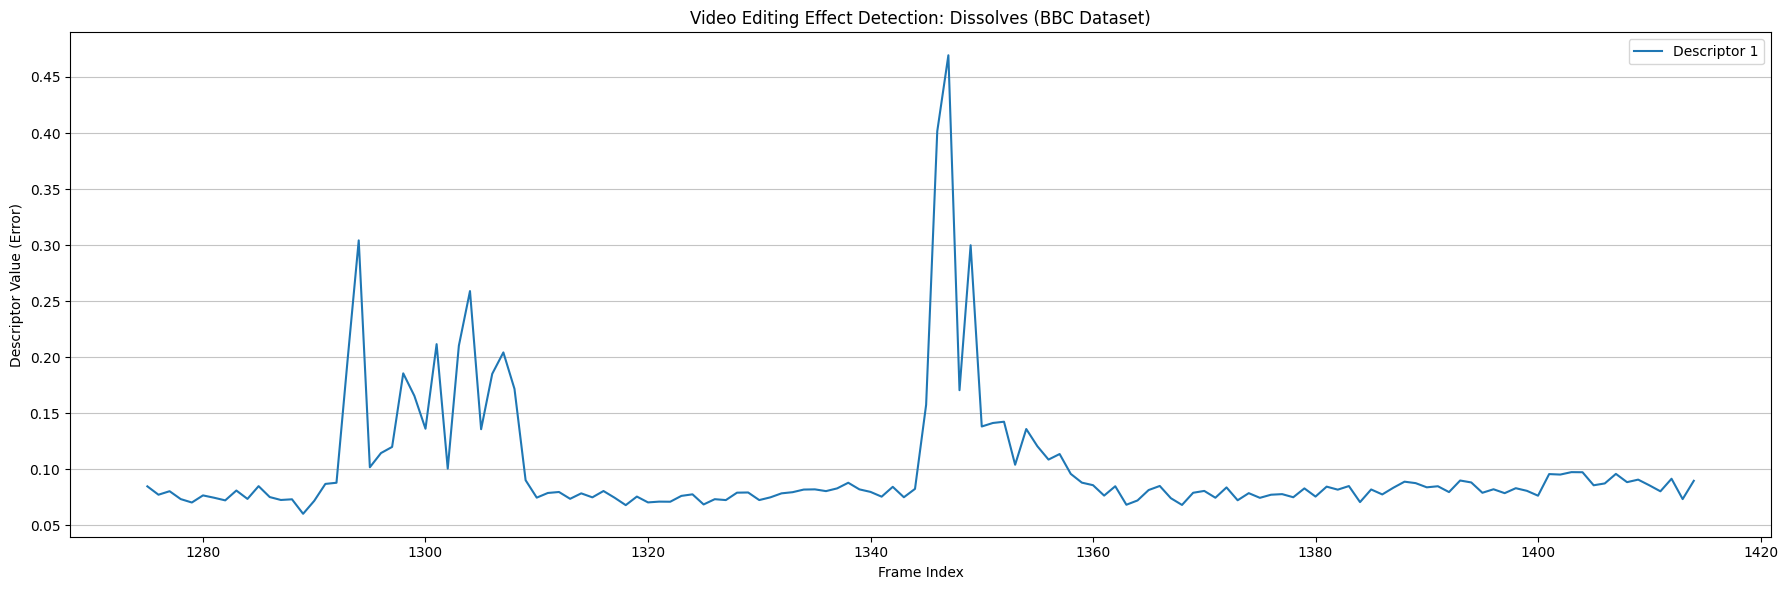

In [19]:
plt.figure(figsize=(18, 6))

plt.plot(idx[1260:1400], errors[1260:1400, 0], label='Descriptor 1')


plt.xlabel('Frame Index')
plt.ylabel('Descriptor Value (Error)')
plt.title('Video Editing Effect Detection: Dissolves (BBC Dataset)')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

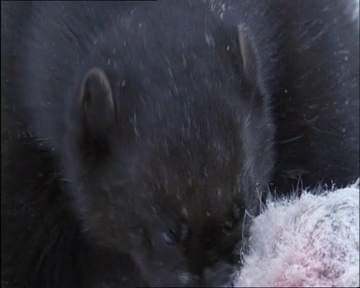

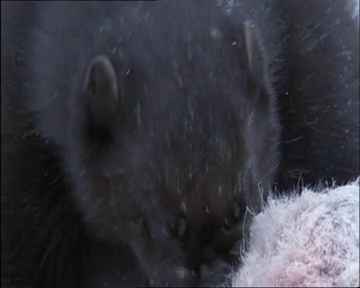

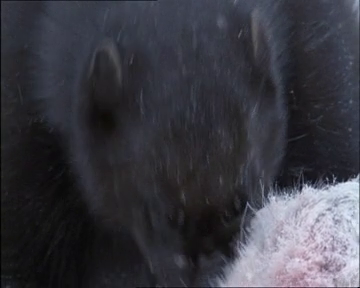

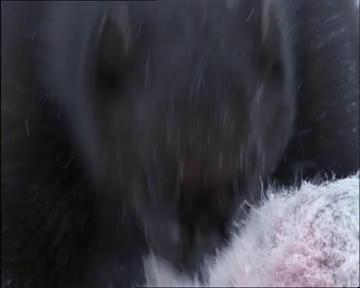

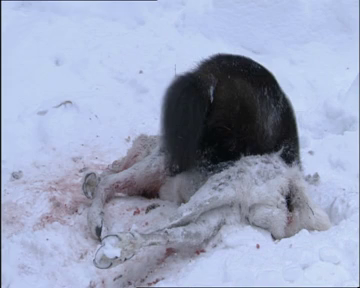

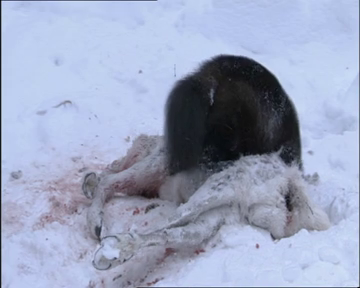

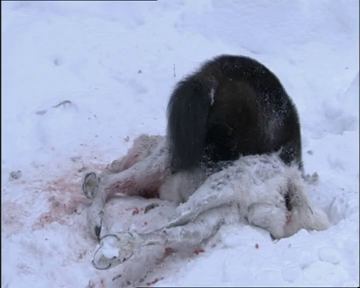

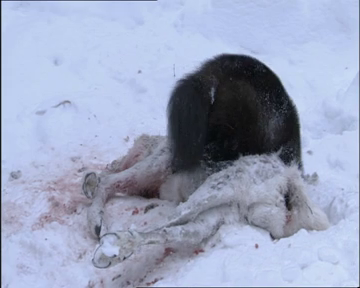

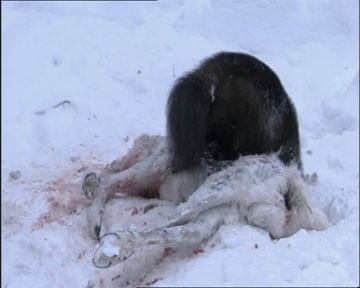

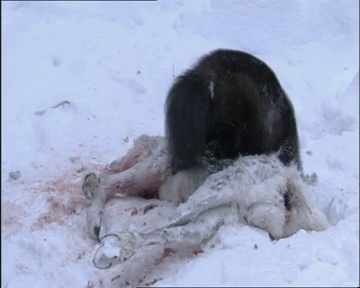

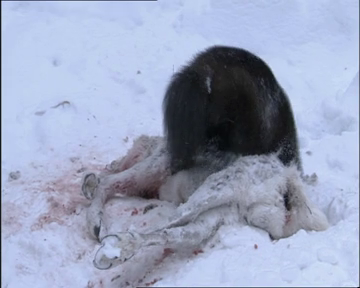

In [47]:
start_frame =9318
end_frame =9328
visualize_frames(video_path, start_frame, end_frame)

In [48]:
# PCA 2D

# Standardize the data
scaler = StandardScaler()
feature_matrix = np.squeeze(errors)
normalized_feature_matrix = scaler.fit_transform(feature_matrix)

pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(normalized_feature_matrix)

In [50]:
# Path to your ground truth text file
gt_file_path = data_path + "/06_Seasonal_Forests.txt"

# Initialize gt with zeros based on the max index found in the video processing
total_frames = idx.max() + 1
gt = np.zeros(total_frames)

try:
    with open(gt_file_path, 'r') as f:
        for line in f:
            # Split the line by whitespace or comma to get start and end frames
            parts = line.strip().split()
            if len(parts) >= 2:
                start_f = int(parts[0])
                end_f = int(parts[1])
                
                # Mark the range in the ground truth array
                # Ensure we stay within bounds
                if start_f < total_frames:
                    gt[start_f:min(end_f + 1, total_frames)] = 1
    
    print(f"Successfully loaded ground truth from {gt_file_path}")
    print(f"Total frames marked as transitions: {int(np.sum(gt))}")
except FileNotFoundError:
    print(f"Error: File {gt_file_path} not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded ground truth from /content/drive/My Drive/DIP_project/06_Seasonal_Forests.txt
Total frames marked as transitions: 73287


(682, 2)
(73272, 2)


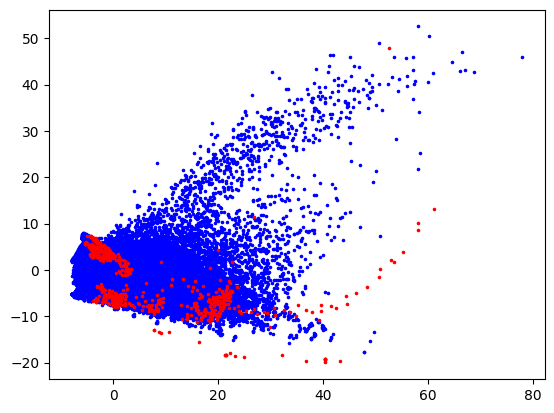

In [51]:
blue_points = []
red_points = []

for i in range(errors.shape[0]):
    if idx[i] < gt.shape[0]:
        if gt[idx[i]] == 1:
            blue_points.append(principal_components[i])
        else:
            red_points.append(principal_components[i])

# Convert to NumPy arrays for efficient plotting
blue_points = np.array(blue_points)
red_points = np.array(red_points)

print(red_points.shape)
print(blue_points.shape)

# Batch plot the points
if blue_points.size > 0:
    plt.scatter(blue_points[:, 0], blue_points[:, 1], c='blue', s=2.5)
if red_points.size > 0:
    plt.scatter(red_points[:, 0], red_points[:, 1], c='red', s=2.5)

plt.show()

In [52]:
# K-Means Clustering
k = 2
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
cluster_labels = kmeans.fit_predict(principal_components)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


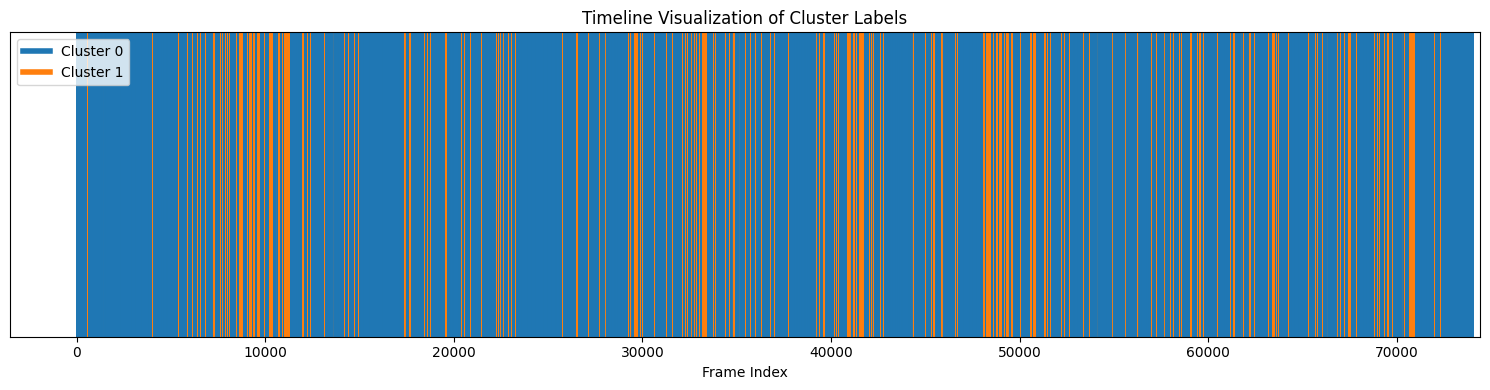

In [53]:
# Visualizing Cluster Labels
unique_labels = np.unique(cluster_labels)
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(unique_labels))]
colors_dict = {label: colors[i] for i, label in enumerate(unique_labels)}


plt.figure(figsize=(15, 4))

for i, label in enumerate(cluster_labels):
    color = colors_dict[label]
    plt.axvline(x=idx[i], ymin=0, ymax=1, color=color, linewidth=2)

for i, label in enumerate(unique_labels):
    plt.axvline(x=0, ymin=0, ymax=0, color=colors[i], label=f'Cluster {label}', linewidth=4)

plt.xlabel('Frame Index')
plt.yticks([])
plt.title('Timeline Visualization of Cluster Labels')
plt.grid(axis='x')
plt.tight_layout()
plt.legend()
plt.show()

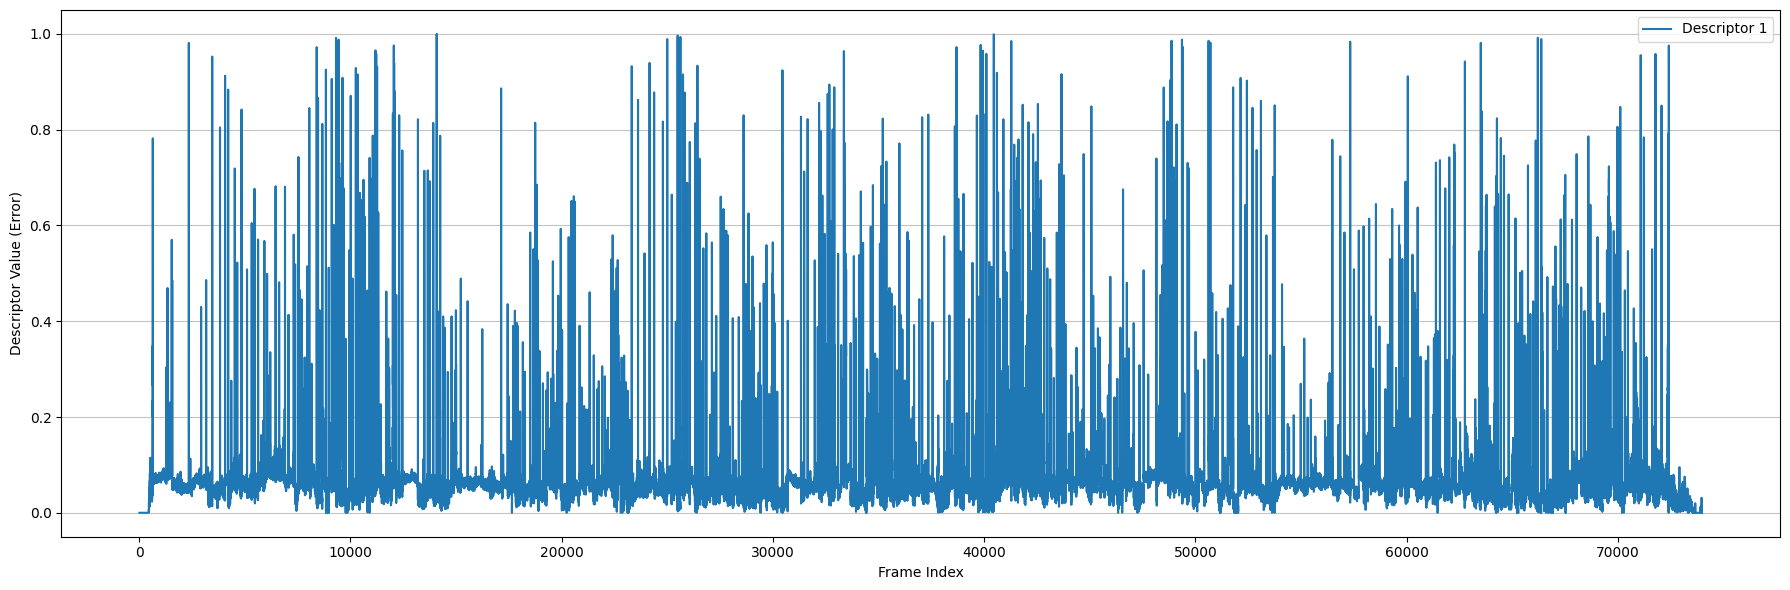

In [54]:
plt.figure(figsize=(18, 6))

plt.plot(idx, errors[:,0], label='Descriptor 1')

plt.xlabel('Frame Index')
plt.ylabel('Descriptor Value (Error)')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

(60647, 2)
(13292, 2)


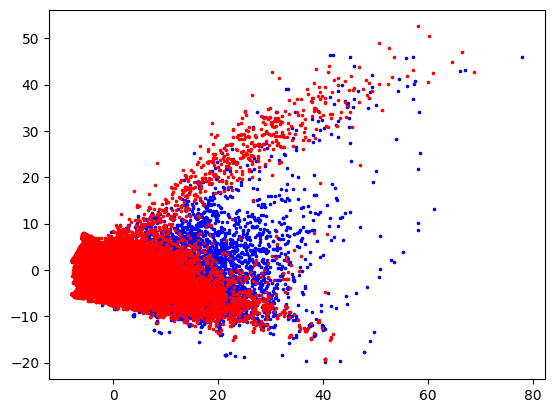

In [55]:
blue_points = []
red_points = []

for i in range(errors.shape[0]):
    if idx[i] < cluster_labels.shape[0]:
        if cluster_labels[idx[i]] == 1:
            blue_points.append(principal_components[i])
        else:
            red_points.append(principal_components[i])

# Convert to NumPy arrays for efficient plotting
blue_points = np.array(blue_points)
red_points = np.array(red_points)

print(red_points.shape)
print(blue_points.shape)

# Batch plot the points
if blue_points.size > 0:
    plt.scatter(blue_points[:, 0], blue_points[:, 1], c='blue', s=2.5)
if red_points.size > 0:
    plt.scatter(red_points[:, 0], red_points[:, 1], c='red', s=2.5)

plt.show()

In [56]:
# SVM

# create labels
labels = np.zeros(errors.shape[0])
for i in range(errors.shape[0]):
    if idx[i] < gt.shape[0]:
        labels[i] = gt[idx[i]]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(feature_matrix, labels, test_size=0.3, random_state=42)

# Create an SVM model with a linear kernel
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [57]:
# Predict the labels of the test set
y_pred = svm_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 99.02%
Confusion Matrix:
[[    2   217]
 [    0 21968]]
